In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

TensorFlow Version: 2.21.0
NumPy Version: 2.2.6


In [11]:
import tensorflow as tf

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

# Skip unreadable images
train_ds = train_ds.ignore_errors()
val_ds = val_ds.ignore_errors()

Found 24959 files belonging to 2 classes.
Using 19968 files for training.
Using 4991 files for validation.


In [12]:
# Normalize pixel values

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [13]:
# Data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Data Augmentation
    data_augmentation,

    # Normalize
    

    # First CNN Block
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Second CNN Block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Third CNN Block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Dense Layer
    layers.Dense(128, activation='relu'),

    # Dropout
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(2, activation='softmax')
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    
    
    
    
    
    callbacks=[early_stop]
)

Epoch 1/15
    618/Unknown 152s 236ms/step - accuracy: 0.5820 - loss: 0.6748

c:\Users\hp\OneDrive\Documents\CNN_Project\venv\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


618/618 ━━━━━━━━━━━━━━━━━━━━ 162s 252ms/step - accuracy: 0.6210 - loss: 0.6472 - val_accuracy: 0.6997 - val_loss: 0.5864
Epoch 2/15
618/618 ━━━━━━━━━━━━━━━━━━━━ 156s 252ms/step - accuracy: 0.6845 - loss: 0.5987 - val_accuracy: 0.7471 - val_loss: 0.5231
Epoch 3/15
618/618 ━━━━━━━━━━━━━━━━━━━━ 156s 252ms/step - accuracy: 0.7129 - loss: 0.5627 - val_accuracy: 0.7592 - val_loss: 0.4975
Epoch 4/15
618/618 ━━━━━━━━━━━━━━━━━━━━ 190s 307ms/step - accuracy: 0.7333 - loss: 0.5350 - val_accuracy: 0.7750 - val_loss: 0.4733
Epoch 5/15
618/618 ━━━━━━━━━━━━━━━━━━━━ 149s 240ms/step - accuracy: 0.7412 - loss: 0.5231 - val_accuracy: 0.7828 - val_loss: 0.4482
Epoch 6/15
618/618 ━━━━━━━━━━━━━━━━━━━━ 148s 239ms/step - accuracy: 0.7579 - loss: 0.5007 - val_accuracy: 0.7996 - val_loss: 0.4320
Epoch 7/15
618/618 ━━━━━━━━━━━━━━━━━━━━ 149s 241ms/step - accuracy: 0.7632 - loss: 0.4942 - val_accuracy: 0.7992 - val_loss: 0.4289
Epoch 8/15
618/618 ━━━━━━━━━━━━━━━━━━━━ 156s 252ms/step - accuracy: 0.7770 - loss: 0.47

In [ ]:
import os
from PIL import Image

dataset_path = "dataset"

for folder in ["cats", "dogs"]:
    folder_path = os.path.join(dataset_path, folder)

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        try:
            img = Image.open(file_path)
            img.verify()   # Verify image integrity
        except:
            print("Removing:", file_path)
            os.remove(file_path)

print("Corrupted images removed successfully!")

Removing: dataset\cats\Thumbs.db


c:\Users\hp\OneDrive\Documents\CNN_Project\venv\lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removing: dataset\dogs\Thumbs.db
Corrupted images removed successfully!


In [ ]:
from PIL import Image
import os

for folder in ["cats", "dogs"]:
    folder_path = os.path.join("dataset", folder)

    for file in os.listdir(folder_path):
        path = os.path.join(folder_path, file)

        try:
            img = Image.open(path)
            img.load()   # Fully read the image
        except Exception as e:
            print("Corrupted:", path)
            print(e)

In [4]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

# Ignore corrupted images
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = val_ds.apply(tf.data.experimental.ignore_errors())

Found 24959 files belonging to 2 classes.
Using 19968 files for training.
Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
Found 24959 files belonging to 2 classes.
Using 4991 files for validation.


In [15]:
from PIL import Image
import os

bad_files = []

for folder in ["cats", "Dog"]:   # Capital D
    folder_path = os.path.join("dataset", folder)

    for file in os.listdir(folder_path):
        path = os.path.join(folder_path, file)

        try:
            img = Image.open(path)
            img.load()
        except Exception:
            bad_files.append(path)

print("Bad files found:", len(bad_files))
print(bad_files)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'dataset\\Dog'

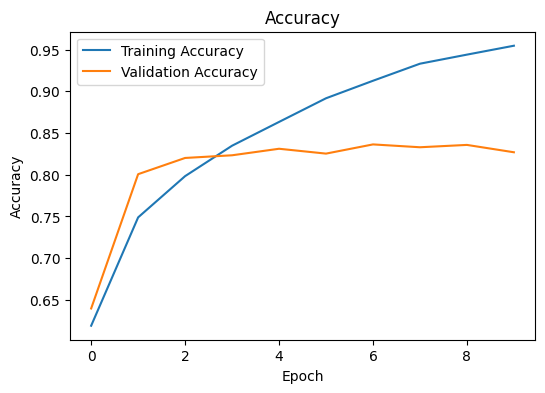

In [13]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("outputs/accuracy.png")   # Save image
plt.show()

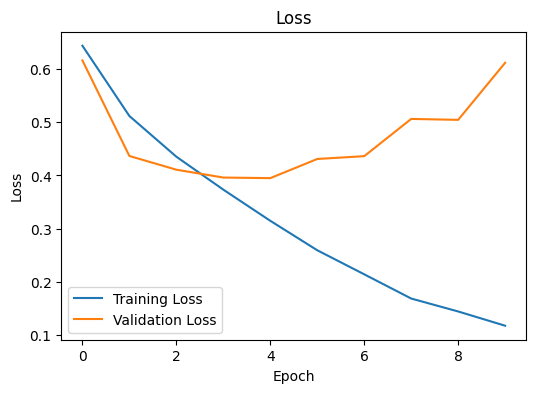

In [14]:
import matplotlib.pyplot as plt

# Loss Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("outputs/loss.png")      # Save image
plt.show()

In [18]:
model.save("models/cnn_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [20]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("dataset/cats/0.jpg", target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

classes = ["cats", "dogs"]

print("Prediction:", classes[np.argmax(prediction)])
print("Confidence:", np.max(prediction)*100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
Prediction: cats
Confidence: 61.716644 %


In [21]:
loss, accuracy = model.evaluate(val_ds)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy * 100, "%")

156/156 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.8415 - loss: 0.3402
Test Loss: 0.3402024805545807
Test Accuracy: 84.15147066116333 %


c:\Users\hp\OneDrive\Documents\CNN_Project\venv\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [2]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(128,128,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\hp\OneDrive\Documents\CNN_Project\venv\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
    618/Unknown 168s 267ms/step - accuracy: 0.5642 - loss: 0.6782

c:\Users\hp\OneDrive\Documents\CNN_Project\venv\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


618/618 ━━━━━━━━━━━━━━━━━━━━ 187s 296ms/step - accuracy: 0.6191 - loss: 0.6440 - val_accuracy: 0.6398 - val_loss: 0.6163
Epoch 2/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 218s 353ms/step - accuracy: 0.7489 - loss: 0.5118 - val_accuracy: 0.8006 - val_loss: 0.4366
Epoch 3/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 165s 266ms/step - accuracy: 0.7983 - loss: 0.4353 - val_accuracy: 0.8201 - val_loss: 0.4108
Epoch 4/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 180s 291ms/step - accuracy: 0.8347 - loss: 0.3733 - val_accuracy: 0.8233 - val_loss: 0.3960
Epoch 5/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 153s 248ms/step - accuracy: 0.8632 - loss: 0.3147 - val_accuracy: 0.8311 - val_loss: 0.3949
Epoch 6/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 149s 241ms/step - accuracy: 0.8916 - loss: 0.2593 - val_accuracy: 0.8253 - val_loss: 0.4310
Epoch 7/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 151s 245ms/step - accuracy: 0.9126 - loss: 0.2140 - val_accuracy: 0.8363 - val_loss: 0.4362
Epoch 8/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 149s 240ms/step - accuracy: 0.9330 - loss: 0.16

In [6]:
model.save("models/cnn_model.h5")

In [7]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

156/156 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.8269 - loss: 0.6119
Validation Accuracy: 0.826888382434845


In [9]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

print(train_dataset.class_names)

Found 24959 files belonging to 2 classes.
Using 19968 files for training.
['cats', 'dogs']
